In [1]:
# R2_CAR171_Canopus.ipynb
# Estimating the stray-light from Canopus star for the Commissioning Activity Request (CAR) 171. 
# This notebook is based on the R1_Rosalia_stray_example.ipynb notebook, but it is adapted to the specific case of Canopus.
# - Alejandro S. Borlaff / NASA Ames / a.s.borlaff@nasa.gov. March 11, 2026.
import rosalia as rs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time

import os
plt.style.use(os.path.dirname(rs.__file__) + "/style/nature_style.mplstyle")


In [2]:
print("Rosalia version:", rs.__version__)

Rosalia version: 0.9.6


In [3]:
# Let's find Canopus (alpha Carinae), the star selected for CAR171. 
# This star is in the continuous viewing zone of Roman, and it is the second brightest star in the sky.
import astropy.units as u
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord

alfCar = Simbad.query_object('Canopus')
ra_star = alfCar["ra"][0]
dec_star = alfCar["dec"][0]

target = SkyCoord(ra_star*u.deg, dec_star*u.deg, frame="icrs")
print(target)


<SkyCoord (ICRS): (ra, dec) in deg
    (95.98795783, -52.69566138)>


In [4]:
# Equatorial pole Test
from astropy.coordinates import get_body
date = Time('2026-07-01T00:00:00.0', format='isot', scale='utc')

sun_coord = get_body('Sun', date)   # get coordinate object for the Sun for each day of the year

ecliptic_pole = SkyCoord(0*u.deg, 89*u.deg, frame="barycentricmeanecliptic")
ecliptic_pole = ecliptic_pole.transform_to("icrs")
bestPA_for_canopus_Dec26 = rs.telescopes.Roman.get_bestPA(ra=ra_star, dec=dec_star, mjd=date.mjd)
print(bestPA_for_canopus_Dec26)
offset_pointing = rs.telescopes.Roman.find_wfi_center_for_offset_target(ra_target=ecliptic_pole.ra.degree,
                                                      dec_target=ecliptic_pole.dec.degree,
                                                      mjd=date.mjd,
                                                      dX=0, dY=0)
print(offset_pointing)
print(sun_coord.barycentricmeanecliptic)

3.433914460691109
{'ra_wficen': 272.51260008821055, 'dec_wficen': 66.54059930452142, 'PA_WFI_offset': -66.52387659834767, 'V3PA_offset': -6.523876598347677, 'V3PA_origin': -6.523876598347678}
<SkyCoord (BarycentricMeanEcliptic: equinox=J2000.000): (lon, lat, distance) in (deg, deg, AU)
    (251.19460248, 1.08182274, 0.00564382)>


In [17]:
print(rs.telescopes.Roman.get_bestPA(ra=ra_star, dec=dec_star, mjd=date.mjd))


152.35596676538606


(-90.0, 90.0)

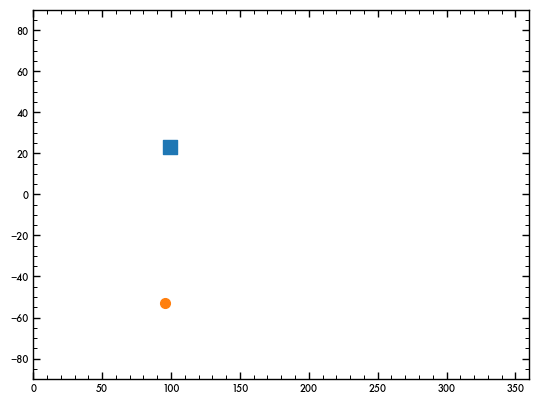

In [6]:
sun_ra = sun_coord.ra.degree
sun_dec = sun_coord.dec.degree
plt.scatter(sun_ra, sun_dec, marker="s", s=100)
plt.scatter(ra_star, dec_star, marker="o")
plt.xlim((0,360))
plt.ylim((-90,90))

In [7]:
sun_dec

23.14173580890076

In [8]:
CAR171 = pd.read_csv("CAR171_v2_coordinates.csv")
CAR171

,Unnamed: 0,Activity name,CAR,Region,Lite?,Possible descope,MPA_ThetaX,MPA_ThetaY,Target source,RA_Source,Dec_Source,N_FRAME,N_EXP,N_FILT,Time,Filter(s),Notes
0,0,SCA14_vertical,171.1,Outer PSF,True,False,0.273006,0.114867,Eta Uma,206.885157,49.313267,55,2,1,8.8,F158,Risk reduction
1,1,SCA14_horizontal,171.1,Outer PSF,True,False,0.204398,0.147970,Eta Uma,206.885157,49.313267,55,2,1,8.8,F158,Risk reduction
2,2,SCA5_vertical,171.1,Outer PSF,True,False,-0.271268,0.115067,Eta Uma,206.885157,49.313267,55,2,1,8.8,F158,Risk reduction
3,3,SCA5_horizontal,171.1,Outer PSF,True,False,-0.202638,0.148120,Eta Uma,206.885157,49.313267,55,2,1,8.8,F158,Risk reduction
4,4,SCA14_cen,171.1,Inner PSF,True,False,0.204400,0.082336,HD128998,219.563423,54.023340,55,2,1,8.8,F158,Risk reduction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,77,SCAN_DRAGON2,171.2,Outer stray,True,False,-0.140800,-0.008300,Canopus,95.987958,-52.695661,55,4,1,14.3,?,Corner light shield scan
78,78,SCAN_DRAGON2,171.2,Outer stray,True,False,-0.135200,-0.008300,Canopus,95.987958,-52.695661,55,4,1,14.3,?,Corner light shield scan
79,79,SCAN_DRAGON2,171.2,Outer stray,True,False,-0.132400,-0.003500,Canopus,95.987958,-52.695661,55,4,1,14.3,?,Corner light shield scan
80,80,NEGATIVE_1,171.2,Outer stray,True,False,-0.066500,-0.175400,Canopus,95.987958,-52.695661,55,4,1,14.3,?,Gap between SCA11 and SCA12


In [9]:
# These are the coordinates of specially sensitive locations 
# for stray-light, measured in offset degrees from the center of WFI focal plane

# Small example coordinates. 
#dX = np.array([-3.7, 3.7, 6.05, 2.45, -2.45, -6.05, -2, 2, -1.3, 1.3, -0.0688, 0.0688, -0.138, 0.138, -0.0665, 0.0665])
#dY = np.array([5.27, 5.27, 1.18, -5.07, -5.07, 1.18, 6.15, 6.15, 1, 1, -0.0312, -0.0312, -0.0035, -0.0048, -0.1754, -0.1754])

CAR171 = pd.read_csv("CAR171_v2_coordinates.csv")
dX = CAR171["MPA_ThetaX"]
dY = CAR171["MPA_ThetaY"]
ra_source = CAR171["RA_Source"]
dec_source = CAR171["Dec_Source"]
number_of_points_of_interest = len(dX)

# To measure the stray-light from those sources, we need to place the center 
# of Roman / WFI at a certain distance and position angle from the source 
# that generates the stray-light. We will name that source the "offending" source. 

# ROSALIA has a specific tool to compute those locations. 

# The optimal position angle of Roman depends with time. 
# Let's set an approximate time for the Commissioning Activities
date = Time('2026-12-01T00:00:00.0', format='isot', scale='utc')

ra_wfi = np.zeros(number_of_points_of_interest)
dec_wfi = np.zeros(number_of_points_of_interest)
V3PA_ori = np.zeros(number_of_points_of_interest)
V3PA_off = np.zeros(number_of_points_of_interest)
WFIPA_off = np.zeros(number_of_points_of_interest)

activity_name_apt = []
category = []
description = []
for i in range(number_of_points_of_interest):
    offset_pointing = rs.telescopes.Roman.find_wfi_center_for_offset_target(ra_target=ra_source[i],
                                                      dec_target=dec_source[i],
                                                      mjd=date.mjd,
                                                      dX=dX[i], dY=dY[i])
    ra_wfi[i] = offset_pointing["ra_wficen"]
    dec_wfi[i] = offset_pointing["dec_wficen"]
    WFIPA_off[i] = offset_pointing["PA_WFI_offset"]%360
    V3PA_off[i] = offset_pointing["V3PA_offset"]%360
    V3PA_ori[i] = offset_pointing["V3PA_origin"]%360
    # v3pa[i] = offset_pointing["PA_v3"] % 360
    activity_name_apt.append(CAR171["Activity name"].iloc[i]+"_"+str(i+1).zfill(3))
    category.append("Calibration")
    description.append("Stray light test")

car171_APT = pd.DataFrame({"Target": activity_name_apt, "ArchiveTarget": activity_name_apt, "description":description, "category": category, "RA": ra_wfi, "DEC": dec_wfi, 
                           "WFIPA_off": WFIPA_off, "V3PA_off": V3PA_off, "V3PA_ori": V3PA_ori})
car171_APT.to_csv("CAR171_apt_targets.csv")


In [10]:
car171_APT

,Target,ArchiveTarget,description,category,RA,DEC,WFIPA_off,V3PA_off,V3PA_ori
0,SCA14_vertical_001,SCA14_vertical_001,Stray light test,Calibration,206.763755,49.027914,82.679576,142.679576,142.770046
1,SCA14_horizontal_002,SCA14_horizontal_002,Stray light test,Calibration,206.700268,49.091727,82.631284,142.631284,142.770046
2,SCA5_vertical_003,SCA5_vertical_003,Stray light test,Calibration,206.656505,49.567671,82.596268,142.596268,142.770046
3,SCA5_horizontal_004,SCA5_horizontal_004,Stray light test,Calibration,206.619657,49.495349,82.568504,142.568504,142.770046
4,SCA14_cen_005,SCA14_cen_005,Stray light test,Calibration,219.397343,53.825870,94.339052,154.339052,154.472328
...,...,...,...,...,...,...,...,...,...
77,SCAN_DRAGON2_078,SCAN_DRAGON2_078,Stray light test,Calibration,96.011116,-52.555319,92.337307,152.337307,152.355967
78,SCAN_DRAGON2_079,SCAN_DRAGON2_079,Stray light test,Calibration,96.010741,-52.560915,92.337611,152.337611,152.355967
79,SCAN_DRAGON2_080,SCAN_DRAGON2_080,Stray light test,Calibration,96.002663,-52.563516,92.344048,152.344048,152.355967
80,NEGATIVE_1_081,NEGATIVE_1_081,Stray light test,Calibration,96.281239,-52.636063,92.121925,152.121925,152.355967


In [11]:
car171_APT

,Target,ArchiveTarget,description,category,RA,DEC,WFIPA_off,V3PA_off,V3PA_ori
0,SCA14_vertical_001,SCA14_vertical_001,Stray light test,Calibration,206.763755,49.027914,82.679576,142.679576,142.770046
1,SCA14_horizontal_002,SCA14_horizontal_002,Stray light test,Calibration,206.700268,49.091727,82.631284,142.631284,142.770046
2,SCA5_vertical_003,SCA5_vertical_003,Stray light test,Calibration,206.656505,49.567671,82.596268,142.596268,142.770046
3,SCA5_horizontal_004,SCA5_horizontal_004,Stray light test,Calibration,206.619657,49.495349,82.568504,142.568504,142.770046
4,SCA14_cen_005,SCA14_cen_005,Stray light test,Calibration,219.397343,53.825870,94.339052,154.339052,154.472328
...,...,...,...,...,...,...,...,...,...
77,SCAN_DRAGON2_078,SCAN_DRAGON2_078,Stray light test,Calibration,96.011116,-52.555319,92.337307,152.337307,152.355967
78,SCAN_DRAGON2_079,SCAN_DRAGON2_079,Stray light test,Calibration,96.010741,-52.560915,92.337611,152.337611,152.355967
79,SCAN_DRAGON2_080,SCAN_DRAGON2_080,Stray light test,Calibration,96.002663,-52.563516,92.344048,152.344048,152.355967
80,NEGATIVE_1_081,NEGATIVE_1_081,Stray light test,Calibration,96.281239,-52.636063,92.121925,152.121925,152.355967


In [12]:
1/12*360

30.0

In [13]:
rs.telescopes.Roman.DEPRECATED_get_bestPA(96.392257,-46.264827, date.mjd)

-61.610250116264176

0.4989711934156419
[-0.5  -0.25  0.    0.25  0.5 ]
[ 367.5  547.5  727.5  907.5 1087.5]


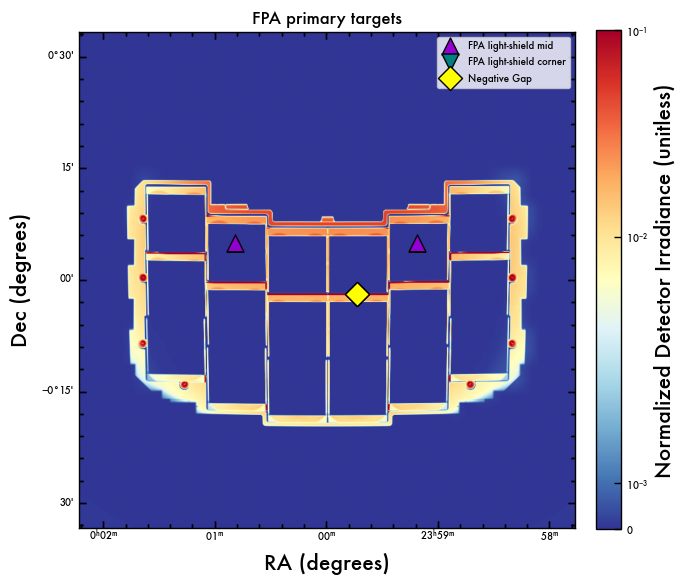

In [14]:
import astropy.wcs as astropy_wcs
import matplotlib.colors as matplotlib_colors

# Plot level 1 NDI 
ndi_name = os.environ["ROSALIACACHE"] + "CORE/NDI/RST/ndi_lvl1_mean.fits"
pa_point = 0
ra_point = 0 
dec_point = 0 
ndi_linthresh = 0.005
if True:
    # Make the modified header based on the exposure properties.
    ndi_fits = fits.open(ndi_name)
    w = astropy_wcs.WCS(header=ndi_fits[0].header, fobj=ndi_fits, naxis=2)
    w.wcs.crota = -pa_point,-pa_point
    w.wcs.crval = ra_point,dec_point
    w.wcs.cdelt = -ndi_fits[0].header["CDELT1"],ndi_fits[0].header["CDELT2"]
    ndi_fits[0].header = w.to_header()

    fig, ax = plt.subplots(1, 1, figsize=(7, 7), subplot_kw=dict(projection=w))

    
    # The transfer NDI maps units of 1/(superpixel size in mm2). 
    # We need to correct by that factor. 
    superpixel_mm2_area = (rs.telescopes.Roman.get_physical_pixelsize("WFI").to("mm").value * 512)**2
    
    im = ax.imshow(np.flip(ndi_fits[0].data/superpixel_mm2_area, axis=1), origin='lower', cmap="RdYlBu_r",
                           norm=matplotlib_colors.SymLogNorm(linthresh=ndi_linthresh, linscale=1,  vmin=0, vmax=1E-1, 
                                            base=10))
    cbar = plt.colorbar(im, ax=ax, location='right', fraction=0.046, pad=0.04)
    cbar.set_label(label='Normalized Detector Irradiance (unitless)',size=15)

    ndi_w = astropy_wcs.WCS(header=ndi_fits[0].header, fobj=ndi_fits, naxis=2)
    # star_catalog = star_catalog_list[i]
    # x_stars, y_stars = ndi_w.wcs_world2pix(star_catalog["ra"], star_catalog["dec"], 0)
    # ax.scatter(x_stars, y_stars, marker="*", color="red", alpha=0.9, s=500)

    #ax.set_title("Stray-light source location on Focal Plane\n", fontsize=16)

    alpha=1

    if True:
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[10], dY[10], 0)
        ax.scatter(x_stars, y_stars, marker="^", edgecolor="black", color="darkviolet", alpha=alpha, s=150, label="FPA light-shield mid")

        x_stars, y_stars = ndi_w.wcs_world2pix(dX[11], dY[11], 0)
        ax.scatter(x_stars, y_stars, marker="^", edgecolor="black", color="darkviolet", alpha=alpha, s=150)



        # CAR 1 B
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[12], dY[12], 0)
        ax.scatter(x_stars, y_stars, marker="v", edgecolor="black", color="teal", alpha=alpha, s=150, label="FPA light-shield corner")

        x_stars, y_stars = ndi_w.wcs_world2pix(dX[13], dY[13], 0)
        ax.scatter(x_stars, y_stars, marker="v", edgecolor="black", color="teal", alpha=alpha, s=150)



        # CAR 1 B
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[68], dY[68], 0)
        ax.scatter(x_stars, y_stars, marker="D", edgecolor="black", color="yellow", alpha=alpha, s=150, label="Negative Gap")

        x_stars, y_stars = ndi_w.wcs_world2pix(dX[69], dY[69], 0)
        ax.scatter(x_stars, y_stars, marker="D", edgecolor="black", color="yellow", alpha=alpha, s=150)


    max_extent_ndi = np.abs(ndi_fits[0].header["CDELT2"]) * ndi_fits[0].data.shape[0]/4.05# This is the radial extent of the NDI map
    print(max_extent_ndi)
    angle_ticks = np.round(np.linspace(-max_extent_ndi, max_extent_ndi, 5),2)
    print(angle_ticks)
    pixel_ticks = angle_ticks/np.abs(ndi_fits[0].header["CDELT2"])  + ndi_fits[0].data.shape[0]/2
    print(pixel_ticks)
    ax.set_xlim(727-400,727+400)
    ax.set_ylim(727-400,727+400)
    #ax.set_xticks(pixel_ticks, angle_ticks, size=12)

    plt.legend(frameon=True)
    #ax.set_yticks(pixel_ticks, angle_ticks, size=12)
    ax.set_xlabel("RA (degrees)", size=15)
    ax.set_ylabel("Dec (degrees)", size=15)
    ax.set_title("FPA primary targets", size=12)
    plt.savefig("ndi_2deg_CARs_with_points.png", dpi=300)
    

10.608333333333546
[-10.6  -5.3   0.    5.3  10.6]
[5.0000e-01 3.1850e+02 6.3650e+02 9.5450e+02 1.2725e+03]


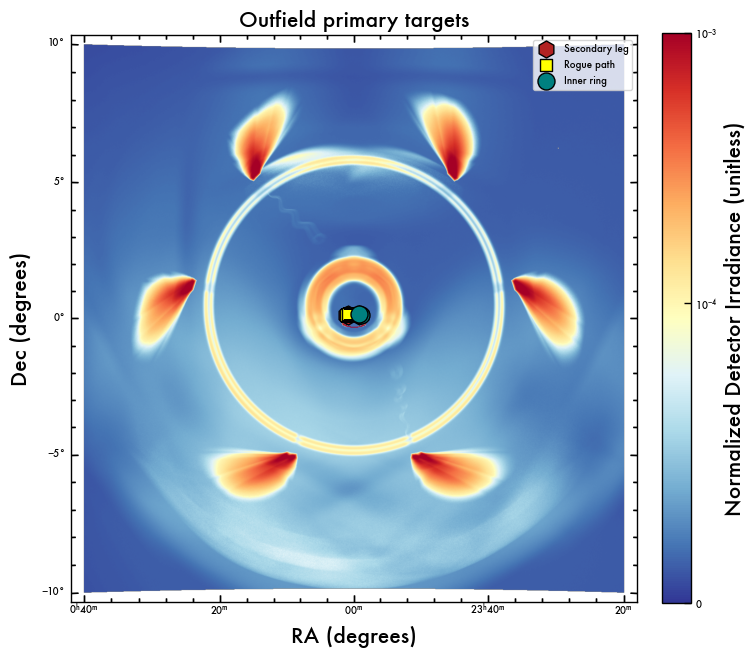

In [15]:
# Plot level 2 NDI 
ndi_name = os.environ["ROSALIACACHE"] + "CORE/NDI/RST/ndi_lvl2_mean.fits"
pa_point = 0
ra_point = 0 
dec_point = 0 
ndi_linthresh = 0.0001
if True:
   
    # Make the modified header based on the exposure properties.
    ndi_fits = fits.open(ndi_name)
    w = astropy_wcs.WCS(header=ndi_fits[0].header, fobj=ndi_fits, naxis=2)
    w.wcs.crota = -pa_point,-pa_point
    w.wcs.crval = ra_point,dec_point
    w.wcs.cdelt = -ndi_fits[0].header["CDELT1"],ndi_fits[0].header["CDELT2"]
    ndi_fits[0].header = w.to_header()
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(projection=w))


    # ndi_header = fits.open(ndi_headerlet)[0].header
    #numcols=0.2
    #numrows=0.2
    im = ax.imshow(ndi_fits[0].data/superpixel_mm2_area, origin='lower', cmap="RdYlBu_r",
                   norm=matplotlib_colors.SymLogNorm(linthresh=ndi_linthresh,  vmin=0, vmax=1E-3, linscale=1, base=10),
                   # extent=(-0.5, numcols-0.5, -0.5, numrows-0.5),
                   # extent=[700,1000,700,1000],
                   )
    #ax.set_xlim(0, 1)
    #ax.set_ylim(0, 1)
    cbar = plt.colorbar(im, ax=ax, location='right', fraction=0.046, pad=0.04)
    cbar.set_label(label='Normalized Detector Irradiance (unitless)',size=15)

    ndi_w = astropy_wcs.WCS(header=ndi_fits[0].header, fobj=ndi_fits, naxis=2)
    # star_catalog = star_catalog_list[i]
    
    # CAR locations 
    alpha = 1
    if True:
        # CAR 1 A
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[0], dY[0], 0)
        ax.scatter(x_stars, y_stars, marker="h", edgecolor="black", color="firebrick", alpha=alpha, s=150, label="Secondary leg")

        # CAR 1 B
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[1], dY[1], 0)
        ax.scatter(x_stars, y_stars, marker="h", edgecolor="black", color="firebrick", alpha=alpha, s=150)

        # CAR 1 C
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[2], dY[2], 0)
        ax.scatter(x_stars, y_stars, marker="h", edgecolor="black", color="firebrick", alpha=alpha, s=150)

        # CAR 1 D
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[3], dY[3], 0)
        ax.scatter(x_stars, y_stars, marker="h", edgecolor="black", color="firebrick", alpha=alpha, s=150)

        # CAR 1 E
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[4], dY[4], 0)
        ax.scatter(x_stars, y_stars, marker="h", edgecolor="black", color="firebrick", alpha=alpha, s=150)

        # CAR 1 F
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[5], dY[5], 0)
        ax.scatter(x_stars, y_stars, marker="h", edgecolor="black", color="firebrick", alpha=alpha, s=150)

        ###################
    
        # CAR 2
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[6], dY[6], 0)
        ax.scatter(x_stars, y_stars, marker="s", edgecolor="black", color="yellow", alpha=alpha, s=75, label="Rogue path")

        #ax.plot([2.2117192, -2.2117192], [6.0719862,  6.0719862], linewidth=3, color="yellow", alpha=alpha)
    
    
        # CAR 2
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[7], dY[7], 0)
        ax.scatter(x_stars, y_stars, marker="s", edgecolor="black", color="yellow", alpha=alpha, s=75)
    
        # CAR 3
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[8], dY[8], 0)
        ax.scatter(x_stars, y_stars, marker="o", edgecolor="black", color="teal", alpha=alpha, s=150, label="Inner ring")

        # CAR 3
        x_stars, y_stars = ndi_w.wcs_world2pix(dX[9], dY[9], 0)
        ax.scatter(x_stars, y_stars, marker="o", edgecolor="black", color="teal", alpha=alpha, s=150)

    
    #ax.set_title("Stray-light source location on Focal Plane\n", fontsize=16)

    max_extent_ndi = np.abs(ndi_fits[0].header["CDELT2"]) * ndi_fits[0].data.shape[0]/2# This is the radial extent of the NDI map
    print(max_extent_ndi)
    angle_ticks = np.round(np.linspace(-max_extent_ndi, max_extent_ndi, 5),1)
    print(angle_ticks)
    pixel_ticks = angle_ticks/np.abs(ndi_fits[0].header["CDELT2"])  + ndi_fits[0].data.shape[0]/2
    print(pixel_ticks)
    #ax.set_xticks(pixel_ticks, angle_ticks, size=12)
    #ax.set_yticks(pixel_ticks, angle_ticks, size=12)
    ax.set_xlabel("RA (degrees)", size=15)
    ax.set_ylabel("Dec (degrees)", size=15)
    ax.set_title("Outfield primary targets", size=15)


    plt.legend(frameon=True)

    plt.savefig("ndi_20deg_CARs_with_points.png", dpi=300)

In [ ]:
CAR171["Activity name"].iloc[i]

In [ ]:

import pandas as pd
canopus_catalog = pd.DataFrame({"ra": ra_star, 
                             "dec": dec_star, 
                             "source_id": "Canopus", 
                             "cat_id": 1,
                             "mag_lambda": -0.74}, index=[0])

# if True:
for i in range(len(ra_wfi)):
    #i = 0
    ra = ra_wfi[i]
    dec = dec_wfi[i]
    pa = WFIPA_off[i]
    mjd = date.mjd
    bandpass="F129"
    exptime=600
    rosalia_stray = rs.correct.rosalia_stray(ra=ra, dec=dec, prefix="CAR171_" + CAR171["Activity name"].iloc[i] + "_",
                                             PA=pa, date=date, bandpass=bandpass, 
                                             exptime=exptime, radius=1, catalog=canopus_catalog,
                                             g_mag_max=17)

In [ ]:
for i in range(number_of_points_of_interest):
    ra = ra_wfi[i]
    dec = dec_wfi[i]
    pa = pa_wfi[i]
    mjd = date.mjd
    bandpass="F129"
    exptime=600
    rosalia_stray = rs.correct.rosalia_stray(ra=ra, dec=dec, 
                                             PA=pa, date=date, bandpass=bandpass, 
                                             exptime=exptime, radius=1,
                                             g_mag_max=15, figsize=(7,6), mu_vmin=22, mu_vmax=27)

In [ ]:
# For the Dragon's Breath example, let's change the target to a dimmer star. 
# Magnitude 2 star. 

# Let's find Canopus (alpha Carinae), the star selected for CAR171. 
# This star is in the continuous viewing zone of Roman, and it is the second brightest star in the sky.
import astropy.units as u
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord

alfUrsae = Simbad.query_object('Mizar')
ra_star = alfUrsae["ra"][0]
dec_star = alfUrsae["dec"][0]

target = SkyCoord(ra_star*u.deg, dec_star*u.deg, frame="icrs")
print(target)

# These are the coordinates of specially sensitive locations 
# for stray-light, measured in offset degrees from the center of WFI focal plane
dX = np.array([-0.0688, 0.0688, -0.138, 0.138])
dY = np.array([-0.0312-20/60/60, -0.0312, -0.0035, -0.0048])
number_of_points_of_interest = len(dX)


# To measure the stray-light from those sources, we need to place the center 
# of Roman / WFI at a certain distance and position angle from the source 
# that generates the stray-light. We will name that source the "offending" source. 

# ROSALIA has a specific tool to compute those locations. 

# The optimal position angle of Roman depends with time. 
# Let's set an approximate time for the Commissioning Activities
from astropy.time import Time
date = Time('2026-11-21T00:00:00.0', format='isot', scale='utc')

ra_wfi = np.zeros(number_of_points_of_interest)
dec_wfi = np.zeros(number_of_points_of_interest)
pa_wfi = np.zeros(number_of_points_of_interest)

for i in range(number_of_points_of_interest):
    offset_pointing = rs.telescopes.Roman.find_wfi_center_for_offset_target(ra_target=target.ra.degree,
                                                      dec_target=target.dec.degree,
                                                      mjd=date.mjd,
                                                      dX=dX[i], dY=dY[i])
    ra_wfi[i] = offset_pointing["ra_wficen"]
    dec_wfi[i] = offset_pointing["dec_wficen"]
    pa_wfi[i] = offset_pointing["pa_wfi"]


In [ ]:
rs.detectors.fe2mu(1, instrument = "WFI", filter_name="F129", telescope="Roman")

In [ ]:
fe2mu_png = rs.plots.make_stray_plot(input_name="/Users/aborlaff/NASA/ROSALIA/notebooks/Dragon_negative_WFI_F129_RA_200.985_DEC_055.003_MJD_61365.00000_PA_063.57_stray_drz_scaled.fits",
                                         ext=1, mode="fe2mu",
                                         color_label = "Surface brightness (mag arcsec$^{-2}$)", 
                                         figsize=(7,6),
                                         mu_vmin=28, 
                                         mu_vmax=22)

stars_around_png = rs.plots.make_stars_around_plot(flt_name="/Users/aborlaff/NASA/ROSALIA/notebooks/Dragon_negative_WFI_F129_RA_200.985_DEC_055.003_MJD_61365.00000_PA_063.57.fits", 
                                                   catalog_name="/Users/aborlaff/NASA/ROSALIA/notebooks/Dragon_negative_WFI_F129_RA_200.985_DEC_055.003_MJD_61365.00000_PA_063.57_source_catalog.csv", 
                                                   output_name=None, figsize=(7,6))


In [ ]:
fe2mu_png = rs.plots.make_stray_plot(input_name="/Users/aborlaff/NASA/ROSALIA/notebooks/Dragon_WFI_F129_RA_200.977_DEC_055.001_MJD_61365.00000_PA_063.57_stray_drz_scaled.fits",
                                         ext=1, mode="fe2mu",
                                         color_label = "Surface brightness (mag arcsec$^{-2}$)", 
                                         figsize=(7,6),
                                         mu_vmin=28, 
                                         mu_vmax=22)


stars_around_png = rs.plots.make_stars_around_plot(flt_name="/Users/aborlaff/NASA/ROSALIA/notebooks/Dragon_WFI_F129_RA_200.977_DEC_055.001_MJD_61365.00000_PA_063.57.fits", 
                                                   catalog_name="/Users/aborlaff/NASA/ROSALIA/notebooks/Dragon_negative_WFI_F129_RA_200.985_DEC_055.003_MJD_61365.00000_PA_063.57_source_catalog.csv", 
                                                   output_name=None, figsize=(7,6))

In [ ]:
# NEGATIVE TARGET 

from astropy.time import Time
date = Time('2026-11-21T00:00:00.0', format='isot', scale='utc')

number_of_points_of_interest = 2
dX_negative = np.array([-0.06651558333333384, 0.06651558333333384]) 
dY_negative = np.array([-0.17538308333333466, -0.17538308333333466])

ra_wfi = np.zeros(number_of_points_of_interest)
dec_wfi = np.zeros(number_of_points_of_interest)
pa_wfi = np.zeros(number_of_points_of_interest)


alfCar = Simbad.query_object('Canopus')
ra_star = alfCar["ra"][0]
dec_star = alfCar["dec"][0]

import pandas as pd
canopus_catalog = pd.DataFrame({"ra": ra_star, 
                             "dec": dec_star, 
                             "source_id": "Canopus", 
                             "cat_id": 1,
                             "mag_lambda": -0.74}, index=[0])


for i in range(number_of_points_of_interest):
    offset_pointing = rs.telescopes.Roman.find_wfi_center_for_offset_target(ra_target=target.ra.degree,
                                                      dec_target=target.dec.degree,
                                                      mjd=date.mjd,
                                                      dX=dX_negative[i], dY=dY_negative[i])
    ra_wfi[i] = offset_pointing["ra_wficen"]
    dec_wfi[i] = offset_pointing["dec_wficen"]
    pa_wfi[i] = offset_pointing["pa_wfi"]


if True:
    i = 1
    ra = ra_wfi[i]
    dec = dec_wfi[i]
    pa = pa_wfi[i]
    mjd = date.mjd
    bandpass="F129"
    exptime=600
    rosalia_stray = rs.correct.rosalia_stray(ra=ra, dec=dec, prefix="Dragon_negative_",
                                             PA=pa, date=date, bandpass=bandpass, 
                                             exptime=exptime, radius=1, catalog=canopus_catalog,
                                             g_mag_max=17)

In [ ]:
texp = (3*60+16)*4 + 200 + 10 
print(texp/60)

In [ ]:
85/6*7

In [ ]:
(200+100+100+382.5+28+184+100+28)/60*(1.15)